# `lit-lobb` — Zhang et al., and the coarse stage that is `ours`' own gate

**One of seven methods** in the Phase 4 comparison (`notes/dataset_plan.md` §4). Two papers
by the same group, and both are needed — the **pipeline** is

> Yuankai Zhang, Yusen Geng, Xincheng Tian, Yujie Sun, Xiaolong Xu.
> *A novel weld seam extraction method with semantic segmentation and point cloud feature
> for irregular structure workpieces.*
> **Robotics and Computer-Integrated Manufacturing 95 (2025) 102987.**

and the **feature descriptor** it calls, its ref. [24], is

> Yuankai Zhang, Yusen Geng, Xincheng Tian, Fuquan Zheng, Yong Jiang, Min Lai.
> *A Feature Extraction Approach Over Workpiece Point Clouds for Robotic Welding.*
> **IEEE Transactions on Automation Science and Engineering 22 (2025) 75–84.**

| stage | here |
|---|---|
| RCIM §3.1 K-Net segmentation into per-**component** masks ("A"/"B"), 97,35% mIoU | `part_labels_oracle` — **an oracle** |
| RCIM §3.2 edge pixels = a neighbourhood holding two masks (eq. 2) | `part_boundary_points` |
| RCIM §3.3 ROI by shape extension: edge cloud as seeds, k-NN expansion | `roi_by_extension` |
| T-ASE §III LOBB: PCA frame, box `(l, w, h)`, flatness / centre offset / corner entropy | `lobb_features` |
| T-ASE §III-C `tanh` activation, then binary K-means per feature | `activate`, `kmeans_1d_binary` |
| RCIM §3.4.2 Mean-Shift density filtering | `mean_shift_keypoints` |
| RCIM §3.4.3 polynomial fit along the dominant axis | `fit_dominant_axis` |

Published accuracy, the reproduction target: **max error < 1,2 mm, RMSE < 0,7 mm**, under 5 s.
LOBB radius **2,5 mm**, chosen "according to the weld width".

## Why this one changes how `ours` should be written up

RCIM eq. 2 declares a pixel an edge when its neighbourhood holds **two different component
masks**. That is `object_id` — exactly what `ours` uses in `cross_object_mask` — obtained from
a trained 2D segmenter instead of from a stack of registered CAD clouds.

`dataset_plan.md` currently frames that gate as *a dependency `ours` does not publish about*,
and records that withholding it costs F1 0,75 → 0,03. **Here is the literature taking the same
dependency and publishing it.** The honest framing is therefore a ladder every method sits on,
not a weakness of one — and the three implemented literature methods sit on three *different*
rungs:

| method | its coarse stage produces | supplied here from |
|---|---|---|
| `lit-ransac` | a **weld-seam band**, ~40 mm wide (PointNet++) | truth seams |
| `lit-regiongrow` | one mask per **surface** (FastSAM) | `face_id` |
| `lit-lobb` | one mask per **component** (K-Net) | `object_id` |

**Everything is millimetres.**

In [1]:
import sys
sys.path.insert(0, "..")            # notebooks/ -> weld_generator/
sys.path.insert(0, "../scripts")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from baselines import balanced_corpus, cloud_for, ground_truth, load_scene, scene_facts
from baselines.lit_lobb import (LOBB_RADIUS_MM, activate, detect, fit_dominant_axis,
                                kmeans_1d_binary, lobb_features, part_boundary_points,
                                part_labels_oracle, roi_by_extension)
from baselines.metrics import (distance_to_polylines, evaluate, matched_path_errors,
                               polyline_length_mm)
from baselines.radius_pca import surface_variation

BENCH = "../out/bench"
CORPUS = balanced_corpus(BENCH, per_type=50)
print({k: len(v) for k, v in CORPUS.items()})
print(f"published LOBB radius {LOBB_RADIUS_MM} mm — a WELD-WIDTH parameter, not a resolution one")


def prepare(joint_types, limit=None):
    out = []
    for jt in joint_types:
        n = 0
        for d in CORPUS[jt]:
            scene, arrays = load_scene(d)
            gt = ground_truth(scene, arrays, primary_only=True)
            if not gt:
                continue
            out.append({"name": d.name, "jt": jt, "facts": scene_facts(scene),
                        "cloud": cloud_for(scene, arrays, view="full"), "gt": gt})
            n += 1
            if limit and n >= limit:
                break
    return out

{'T': 50, 'butt': 50, 'corner': 50, 'edge': 50, 'lap': 50}
published LOBB radius 2.5 mm — a WELD-WIDTH parameter, not a resolution one


## LOBB flatness is not the surface variation the other two methods use

`ours` and `lit-regiongrow` both compute `λ_min / Σλ` — a ratio of eigen**values**, i.e. an
RMS over the neighbourhood. LOBB computes

$$f = \tan\theta = \frac{h}{\sqrt{l^2 + w^2}}$$

over the bounding-box **extents** in the PCA frame — a max-minus-min. Same geometric intent,
different statistic, and the difference is entirely **outlier sensitivity**: one point lifted
off the surface moves `h` completely and `λ₃` hardly at all.

Three of the seven methods now share a feature *family* and differ in the statistic taken over
it. That is a far cleaner comparison axis than any of them being "better".

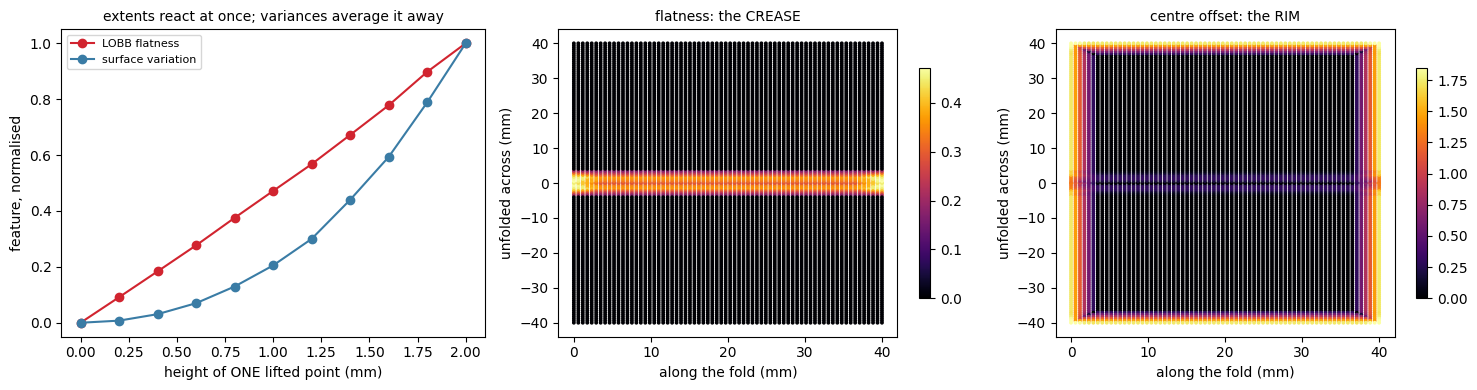

In [2]:
rng = np.random.default_rng(0)
lift = np.linspace(0.0, 2.0, 11)
flat = np.column_stack([rng.uniform(-10, 10, 3000), rng.uniform(-10, 10, 3000),
                        np.zeros(3000)])

rows = []
for z in lift:
    p = flat.copy()
    p[0, 2] = z                                    # ONE point lifted off the plane
    rows.append({"lift_mm": z,
                 "LOBB flatness": lobb_features(p, radius_mm=5.0)["flatness"][0],
                 "surface variation": surface_variation(p, radius_mm=5.0)[0]})
sens = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.0))
for c_, col in (("#d1242f", "LOBB flatness"), ("#3a7ca5", "surface variation")):
    v = sens[col] / max(sens[col].max(), 1e-12)
    axes[0].plot(sens.lift_mm, v, "o-", c=c_, label=col)
axes[0].set_xlabel("height of ONE lifted point (mm)"); axes[0].set_ylabel("feature, normalised")
axes[0].legend(fontsize=8)
axes[0].set_title("extents react at once; variances average it away", fontsize=10)

# The three LOBB features on a real fold, so their division of labour is visible.
a = np.linspace(0, 40, 70)
g2 = np.stack(np.meshgrid(a, a), -1).reshape(-1, 2)
p1 = np.column_stack([g2[:, 0], g2[:, 1], np.zeros(len(g2))])
p2 = np.column_stack([g2[:, 0], np.zeros(len(g2)), g2[:, 1]])
fold = np.vstack([p1, p2])
F = lobb_features(fold, radius_mm=4.0)

for ax, key, ttl in ((axes[1], "flatness", "flatness: the CREASE"),
                     (axes[2], "center_offset", "centre offset: the RIM")):
    sc_ = ax.scatter(fold[:, 0], np.where(fold[:, 2] > 0, fold[:, 2], -fold[:, 1]),
                     c=F[key], s=3, cmap="inferno")
    fig.colorbar(sc_, ax=ax, shrink=0.75)
    ax.set_xlabel("along the fold (mm)"); ax.set_ylabel("unfolded across (mm)")
    ax.set_title(ttl, fontsize=10)
plt.tight_layout(); plt.show()

**Flatness finds the crease; centre offset finds the rim.** That division of labour is the
point of T-ASE §III-B, and it is the one part of any of these three methods that directly
addresses the **face-versus-part** problem: a plate's own border is a *boundary* point, not a
crease, and the hierarchy is supposed to remove it before the crease split ever runs.

`lit-regiongrow` attacks the same problem with `two_surface_edges` and — measured in
notebook `05` — fails, because perfect surface labels make *every* plate edge qualify. Whether
the centre offset does better is the interesting question here.

## Nonlinear activation, and why the K-means needs it

T-ASE §III-C: all four clustering problems are **binary splits of 1-D data**. A 1-D binary
K-means is driven by the mass sitting *between* the two modes, so `tanh` over a bilateral
range is applied first to push that mass outward (eq. 9). Their Fig. 8 shows the split failing
without it — face points misclassified as creases.

The K-means here is written out rather than imported, seeded at the min and max, so it is
**deterministic**. That matters for Phase 4: `lit-ransac` swings F1 0,00–0,94 on one fixed
scene purely on its RANSAC seed, and *"the deterministic methods show zero spread"* is only a
finding if they really are deterministic.

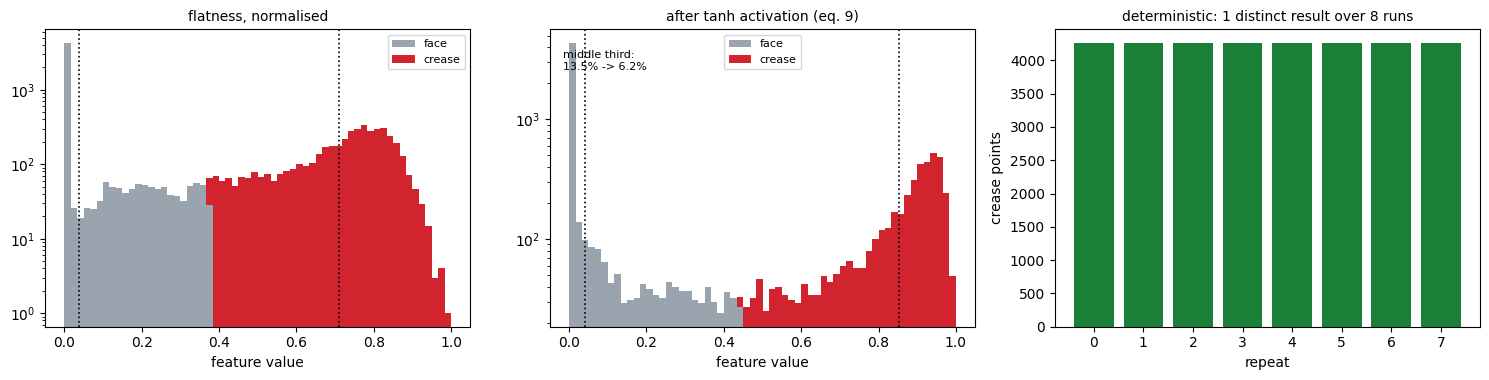

In [3]:
scene0 = prepare(("corner",), limit=1)[0]
c0 = scene0["cloud"]
lab0 = part_labels_oracle(c0["object_id"])
edge0 = part_boundary_points(c0["xyz"], lab0, edge_radius_mm=3.0)
roi0 = roi_by_extension(c0["xyz"], edge0, k=30)
F0 = lobb_features(c0["xyz"][roi0], radius_mm=LOBB_RADIUS_MM)

raw = (F0["flatness"] - F0["flatness"].min()) / max(np.ptp(F0["flatness"]), 1e-12)
act = activate(F0["flatness"])

fig, axes = plt.subplots(1, 3, figsize=(15, 3.9))
for ax, v, ttl in ((axes[0], raw, "flatness, normalised"),
                   (axes[1], act, "after tanh activation (eq. 9)")):
    hi = kmeans_1d_binary(v)
    ax.hist([v[~hi], v[hi]], bins=60, stacked=True, color=["#9aa4ae", "#d1242f"],
            label=["face", "crease"])
    for cc in (v[~hi].mean(), v[hi].mean()):
        ax.axvline(cc, c="k", ls=":", lw=1.2)
    ax.set_yscale("log"); ax.legend(fontsize=8); ax.set_title(ttl, fontsize=10)
    ax.set_xlabel("feature value")
mid = lambda v: float(np.mean((v > 0.35) & (v < 0.65)))   # noqa: E731
axes[1].text(0.03, 0.93, f"middle third:\n{mid(raw):.1%} -> {mid(act):.1%}",
             transform=axes[1].transAxes, fontsize=8, va="top")

# Determinism, asserted in the tests and shown here next to lit-ransac's seed spread.
reps = [kmeans_1d_binary(act).sum() for _ in range(8)]
axes[2].bar(range(len(reps)), reps, color="#1a7f37")
axes[2].set_xlabel("repeat"); axes[2].set_ylabel("crease points")
axes[2].set_title(f"deterministic: {len(set(reps))} distinct result over 8 runs", fontsize=10)
plt.tight_layout(); plt.show()

## One scene, in detail

The corner joint first, because it is the case the pipeline is posed for: **one open contact
run**, so the polynomial at the end has a single seam to fit.

corner joint | ROI 4535 of 197865 | crease 1488 | boundary 943 | 1 seam(s) vs 2 true
  P=0.993  R=1.000  F1=0.996
  RMSE 0.377 mm | ME 4.315 mm | covers 109%
  RCIM reports: max error < 1,2 mm, RMSE < 0,7 mm


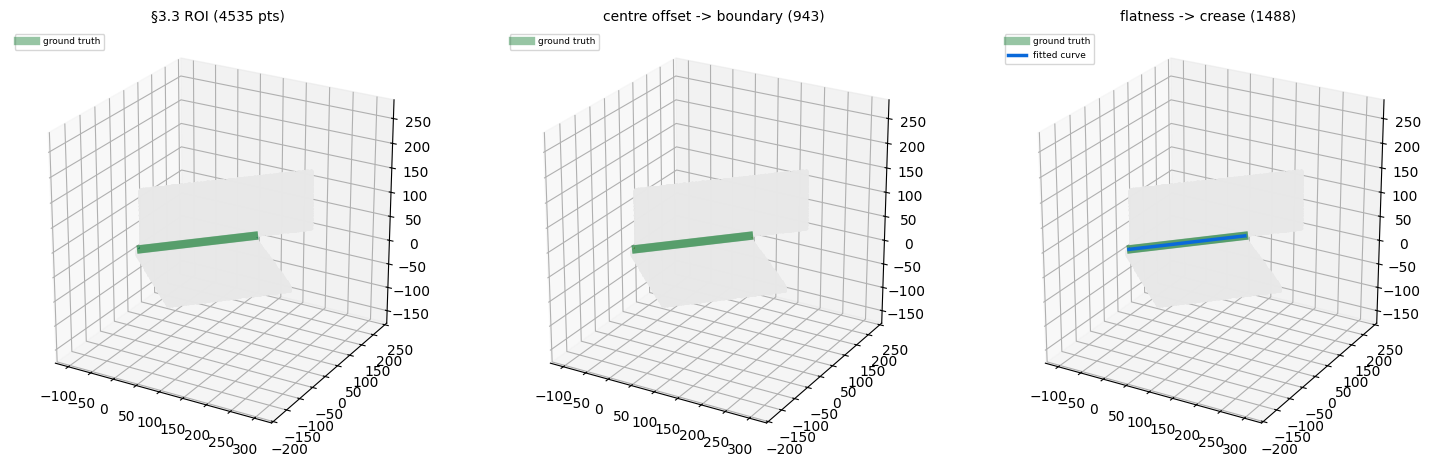

In [4]:
ELEV, AZIM = 24, -60
r0 = detect(c0["xyz"], object_id=c0["object_id"], voxel_mm=1.0)
m0 = evaluate(r0.polylines, scene0["gt"], tol_mm=3.0)
err0 = [e for e in matched_path_errors(r0.polylines, scene0["gt"]) if e["matched"]]
print(f"{scene0['jt']} joint | ROI {int(r0.roi.sum())} of {r0.params['n_input']} | "
      f"crease {int(r0.crease.sum())} | boundary {int(r0.boundary.sum())} | "
      f"{r0.n_seams} seam(s) vs {len(scene0['gt'])} true")
print(f"  P={m0['precision']:.3f}  R={m0['recall']:.3f}  F1={m0['f1']:.3f}")
for e in err0:
    print(f"  RMSE {e['rmse']:.3f} mm | ME {e['me']:.3f} mm | "
          f"covers {100 * e['n_samples'] * 0.25 / max(polyline_length_mm(scene0['gt'][e['gt_index']]), 1e-9):.0f}%")
print("  RCIM reports: max error < 1,2 mm, RMSE < 0,7 mm")

fig = plt.figure(figsize=(15, 4.6))
P = r0.points
c_ = 0.5 * (P.min(0) + P.max(0)); half = 0.55 * float((P.max(0) - P.min(0)).max())

for k, (mask, ttl, col) in enumerate((
        (r0.roi, f"§3.3 ROI ({int(r0.roi.sum())} pts)", "#3a7ca5"),
        (r0.boundary, f"centre offset -> boundary ({int(r0.boundary.sum())})", "#d1842f"),
        (r0.crease, f"flatness -> crease ({int(r0.crease.sum())})", "#d1242f"))):
    ax = fig.add_subplot(1, 3, k + 1, projection="3d")
    ax.scatter(*P[::5].T, s=0.4, c="#e8e8e8", depthshade=False)
    ax.scatter(*P[mask].T, s=3, c=col, alpha=0.6, depthshade=False)
    for j, g in enumerate(scene0["gt"]):
        ax.plot(*np.asarray(g).T, lw=6, c="#1a7f37", alpha=0.45, zorder=8,
                label="ground truth" if j == 0 else None)
    if k == 2:
        for j, s_ in enumerate(r0.seams):
            ax.plot(*s_.T, lw=2.5, c="#0969da", zorder=12,
                    label="fitted curve" if j == 0 else None)
    for i, setter in enumerate((ax.set_xlim, ax.set_ylim, ax.set_zlim)):
        setter(c_[i] - half, c_[i] + half)
    ax.set_box_aspect([1, 1, 1]); ax.view_init(elev=ELEV, azim=AZIM)
    ax.legend(fontsize=6.5, loc="upper left"); ax.set_title(ttl, fontsize=10)
plt.tight_layout(); plt.show()

## The corpus, both arms

`L0` supplies the component masks RCIM §3.1 obtains from K-Net. `L1` withholds them — and
because §3.2's edge test *is* the cross-object gate, withholding them removes the coarse stage
entirely and the whole cloud becomes the ROI.

Watch `ours` and `lit-lobb` together on this axis. They take the same input and should fail
together if the dependency is real.

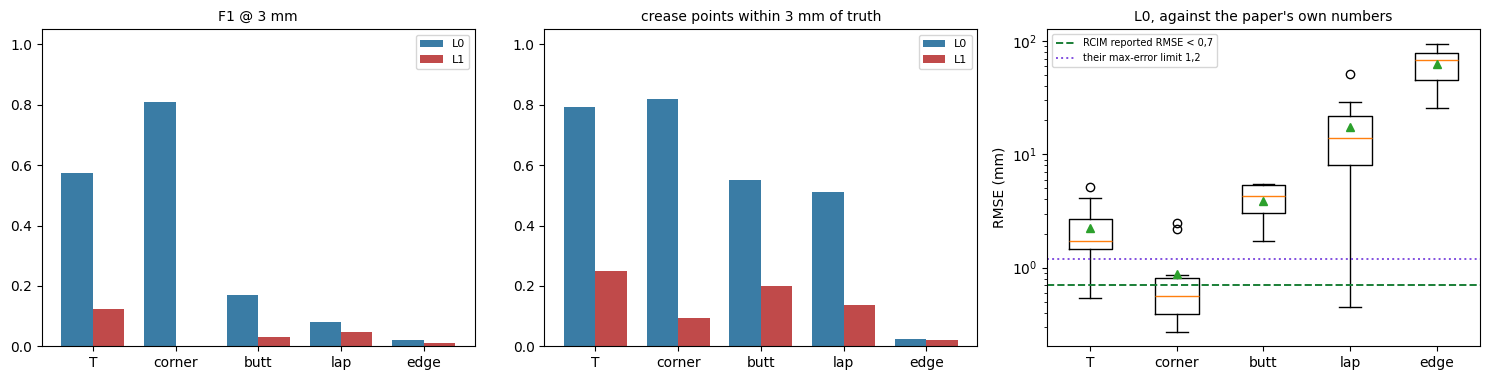

roi   crease  det_med    in3    n  ngt   prec    rec     f1  \
arm jt                                                                         
L0  T         4234.0   1285.0    1.500  0.963  1.0  2.0  0.972  0.500  0.664   
    butt      3352.0    783.0    1.993  0.773  1.0  2.0  0.000  0.000  0.000   
    corner    2561.0    767.0    1.102  0.995  1.0  2.0  0.994  1.000  0.994   
    edge     49318.5  20836.0   56.342  0.018  1.0  1.0  0.005  0.002  0.003   
    lap       7201.5   1051.0    2.062  0.641  1.0  2.0  0.000  0.000  0.000   
L1  T       115354.0   8202.0   44.129  0.191  2.0  2.0  0.000  0.000  0.000   
    butt    135345.0   7418.5   65.902  0.235  7.5  2.0  0.000  0.000  0.000   
    corner  111389.5   8973.5   91.339  0.104  2.5  2.0  0.000  0.000  0.000   
    edge    107498.5  21082.5   61.310  0.015  2.5  1.0  0.000  0.000  0.000   
    lap     120449.5   8201.5   46.544  0.141  2.5  2.0  0.009  0.026  0.011   

              rmse       me  
arm jt                       
L0  T        1.734    4.963  
    butt     4.259    4.907  
    corner   0.564    3.362  
    edge    67.756  109.637  
    lap     13.955   19.229  
L1  T       44.061  102.338  
    butt    46.541   81.957  
    corner  85.591  143.962  
    edge    64.108   85.403  
    lap     38.678   82.564

In [5]:
SCENES = prepare(("T", "corner", "butt", "lap", "edge"), limit=12)
rows = []
for s_ in SCENES:
    for arm, oid in (("L0", s_["cloud"]["object_id"]), ("L1", None)):
        r_ = detect(s_["cloud"]["xyz"], object_id=oid, voxel_mm=1.0)
        m = evaluate(r_.polylines, s_["gt"], tol_mm=3.0)
        e = [x for x in matched_path_errors(r_.polylines, s_["gt"]) if x["matched"]]
        cr = r_.points[r_.crease]
        dd = distance_to_polylines(cr, s_["gt"]) if len(cr) else np.array([np.inf])
        rows.append({"jt": s_["jt"], "arm": arm, "roi": int(r_.roi.sum()),
                     "crease": len(cr), "det_med": float(np.median(dd)),
                     "in3": float((dd <= 3).mean()), "n": r_.n_seams,
                     "ngt": len(s_["gt"]), "prec": m["precision"], "rec": m["recall"],
                     "f1": m["f1"],
                     "rmse": np.median([x["rmse"] for x in e]) if e else np.nan,
                     "me": np.median([x["me"] for x in e]) if e else np.nan})
corp = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.9))
order = [j for j in ["T", "corner", "butt", "lap", "edge"] if j in set(corp.jt)]
x = np.arange(len(order)); w = 0.38
for ax, metric, ttl in ((axes[0], "f1", "F1 @ 3 mm"),
                        (axes[1], "in3", "crease points within 3 mm of truth")):
    for k, arm in enumerate(("L0", "L1")):
        ax.bar(x + (k - 0.5) * w,
               [corp[(corp.jt == j) & (corp.arm == arm)][metric].mean() for j in order],
               w, label=arm, color=["#3a7ca5", "#c04a4a"][k])
    ax.set_xticks(x); ax.set_xticklabels(order); ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8); ax.set_title(ttl, fontsize=10)

L0 = corp[corp.arm == "L0"].dropna(subset=["rmse"])
axes[2].boxplot([L0[L0.jt == j].rmse.values for j in order if (L0.jt == j).any()],
                tick_labels=[j for j in order if (L0.jt == j).any()], showmeans=True)
axes[2].axhline(0.7, c="#1a7f37", ls="--", lw=1.4, label="RCIM reported RMSE < 0,7")
axes[2].axhline(1.2, c="#8250df", ls=":", lw=1.4, label="their max-error limit 1,2")
axes[2].set_yscale("log"); axes[2].set_ylabel("RMSE (mm)"); axes[2].legend(fontsize=7)
axes[2].set_title("L0, against the paper's own numbers", fontsize=10)
plt.tight_layout(); plt.show()

corp.groupby(["arm", "jt"])[["roi", "crease", "det_med", "in3", "n", "ngt",
                             "prec", "rec", "f1", "rmse", "me"]].median().round(3)

## A T joint's contact perimeter is **closed**, and that is what breaks the fit

The corner joint reproduces the paper. The T joint does not, and the reason is not detection:
**98% of its crease points land within 3 mm of truth.**

What fails is cutting them into seams. A web sitting on a base plate touches it along a
**closed perimeter** — two long fillets joined by two short cross-runs at the ends. D4 excludes
the cross-runs as cross-runs, so the *label* is two open curves while the *geometry* is one
loop. LOBB finds the loop almost perfectly and then fits **one** polynomial through it, which
is meaningless for a closed curve.

The cross-runs are only ~2,5% of the crease points, and every one of them sits within 15 mm of
a seam endpoint — but they physically bridge the two fillets, so **no link distance separates
them.**

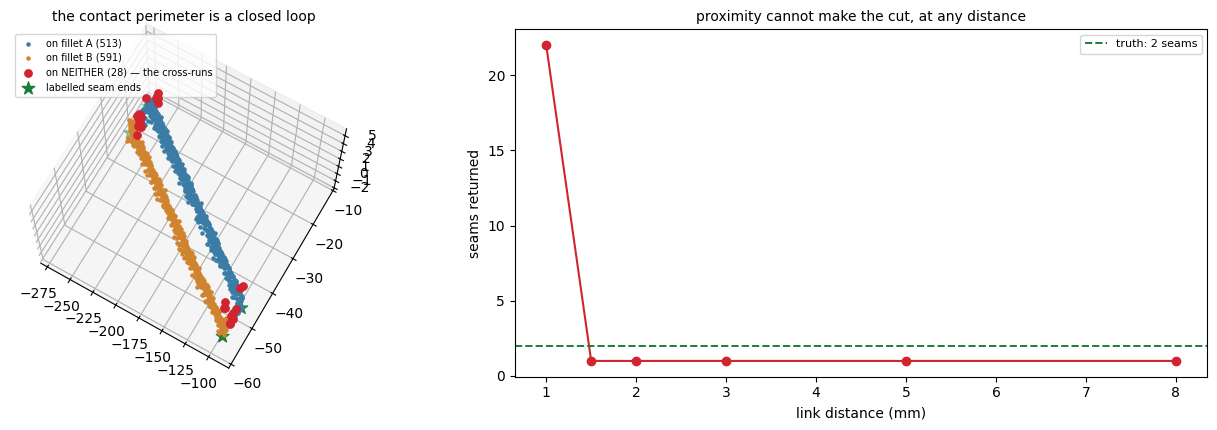

crease points 1132: fillet A 513, fillet B 591, neither 28 (2.5%)
  of those, 100% lie within 15 mm of a labelled seam ENDPOINT (median 3.8 mm) — they are the cross-runs closing the perimeter


In [6]:
tj = prepare(("T",), limit=1)[0]
ct = tj["cloud"]
rt = detect(ct["xyz"], object_id=ct["object_id"], voxel_mm=1.0, link_mm=1.5)
cr = rt.points[rt.crease]
d0 = distance_to_polylines(cr, [tj["gt"][0]])
d1 = distance_to_polylines(cr, [tj["gt"][1]])
on0, on1 = d0 <= 3, d1 <= 3
off = ~(on0 | on1)
ends = np.vstack([tj["gt"][0][0], tj["gt"][0][-1], tj["gt"][1][0], tj["gt"][1][-1]])

fig = plt.figure(figsize=(14, 4.4))
ax = fig.add_subplot(121, projection="3d")
ax.scatter(*cr[on0].T, s=5, c="#3a7ca5", label=f"on fillet A ({on0.sum()})", depthshade=False)
ax.scatter(*cr[on1].T, s=5, c="#d1842f", label=f"on fillet B ({on1.sum()})", depthshade=False)
ax.scatter(*cr[off].T, s=28, c="#d1242f", label=f"on NEITHER ({off.sum()}) — the cross-runs",
           depthshade=False, zorder=10)
ax.scatter(*ends.T, s=90, marker="*", c="#1a7f37", zorder=12, label="labelled seam ends")
ax.legend(fontsize=7, loc="upper left"); ax.view_init(elev=70, azim=AZIM)
ax.set_title("the contact perimeter is a closed loop", fontsize=10)

# No link distance separates them, and that is the point.
ax2 = fig.add_subplot(122)
links = [1.0, 1.5, 2.0, 3.0, 5.0, 8.0]
ns = [detect(ct["xyz"], object_id=ct["object_id"], voxel_mm=1.0, link_mm=L).n_seams
      for L in links]
ax2.plot(links, ns, "o-", c="#d1242f")
ax2.axhline(len(tj["gt"]), c="#1a7f37", ls="--", lw=1.4, label=f"truth: {len(tj['gt'])} seams")
ax2.set_xlabel("link distance (mm)"); ax2.set_ylabel("seams returned")
ax2.legend(fontsize=8)
ax2.set_title("proximity cannot make the cut, at any distance", fontsize=10)
plt.tight_layout(); plt.show()

print(f"crease points {len(cr)}: fillet A {on0.sum()}, fillet B {on1.sum()}, "
      f"neither {off.sum()} ({off.mean():.1%})")
if off.any():
    de = np.linalg.norm(cr[off][:, None, :] - ends[None, :, :], axis=2).min(axis=1)
    print(f"  of those, {(de <= 15).mean():.0%} lie within 15 mm of a labelled seam ENDPOINT "
          f"(median {np.median(de):.1f} mm) — they are the cross-runs closing the perimeter")

## Open questions

- **This is the third method stopped by the same missing primitive.** `ours` cannot separate
  two parallel centrelines a plate-thickness apart; `lit-regiongrow` cannot hold a seam
  together without merging both fillets; `lit-lobb` cannot cut a closed perimeter into the
  open runs that are welded. All three want *split by direction, not proximity*.

  **It is deliberately not added here.** Neither RCIM §3.4.3 nor Wei et al. §III-D specifies a
  clustering step at all — multi-seam clustering is this repo's addition in both. Replacing
  the standard filler with something better than the paper suggests would make the
  reimplementation outperform the published method, which is the same fidelity failure as
  making it worse, and it would leave every number unattributable. `ours` gets the upgrade
  because it is our method; the `lit-*` entries keep Euclidean clustering, declared as a
  deviation. If the question is *how much of each method's error is clustering*, run the
  better splitter as a clearly labelled **diagnostic arm** across all of them, and never quote
  it as a paper's result.
- **Mean-Shift is off by default and should stay off here.** RCIM §3.4.2 justifies it with a
  *sensor* artefact — creases scatter more light, so a structured-light camera returns more
  points there. `area_uniform` sampling is uniform by construction, so the gradient it climbs
  does not exist in this dataset. The faithful path is implemented behind `mean_shift=True`;
  a number produced with it here would not mean what it means in the paper.
- **The single-view arm is untouched.** Their K-Net segments a 2D image, so it only ever sees
  camera-visible surfaces. Everything above is full visibility.
- **The corner joint reproduces the paper on the first run, with no tuning.** That deserves a
  second look rather than celebration: check it is not an artefact of the corner joint having
  exactly one open contact run, by testing a lap joint whose toe is also a single open run.